In [1]:
import pandas as pd
import numpy as np

In [6]:
data=pd.read_csv(r"C:\Users\ACER\Desktop\hypertension_dataset.csv")

In [7]:
data.head(4)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes


In [8]:
data.tail()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No
1984,38,7.3,0,Normal,8.3,18.6,NaN,Yes,Low,Smoker,No


In [9]:
data.isnull().sum

<bound method DataFrame.sum of         Age  Salt_Intake  Stress_Score  BP_History  Sleep_Duration    BMI  \
0     False        False         False       False           False  False   
1     False        False         False       False           False  False   
2     False        False         False       False           False  False   
3     False        False         False       False           False  False   
4     False        False         False       False           False  False   
...     ...          ...           ...         ...             ...    ...   
1980  False        False         False       False           False  False   
1981  False        False         False       False           False  False   
1982  False        False         False       False           False  False   
1983  False        False         False       False           False  False   
1984  False        False         False       False           False  False   

      Medication  Family_History  Exercise_L

In [10]:
data.dropna

<bound method DataFrame.dropna of       Age  Salt_Intake  Stress_Score       BP_History  Sleep_Duration   BMI  \
0      69          8.0             9           Normal             6.4  25.8   
1      32         11.7            10           Normal             5.4  23.4   
2      78          9.5             3           Normal             7.1  18.7   
3      38         10.0            10     Hypertension             4.2  22.1   
4      41          9.8             1  Prehypertension             5.8  16.2   
...   ...          ...           ...              ...             ...   ...   
1980   56         10.2             0           Normal             6.5  25.0   
1981   29          8.9             4     Hypertension             6.9  16.9   
1982   64          5.9             9           Normal             5.6  18.9   
1983   35          7.4             8  Prehypertension             8.2  29.2   
1984   38          7.3             0           Normal             8.3  18.6   

         Medicati

In [11]:
data.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='str')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
X = data.drop("Has_Hypertension", axis=1)
y = data["Has_Hypertension"]

In [ ]:
X = data.drop()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [19]:
from sklearn.model_selection import train_test_split

X = data.drop("Has_Hypertension", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = le.fit_transform(X[column])

In [21]:
# Step 1: encode FIRST
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = le.fit_transform(X[column])

# Step 2: THEN split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
print(X.dtypes)

Age                             int64
Salt_Intake                   float64
Stress_Score                    int64
Sleep_Duration                float64
BMI                           float64
BP_History_Normal                bool
BP_History_Prehypertension       bool
Medication_Beta Blocker          bool
Medication_Diuretic              bool
Medication_Other                 bool
Family_History_Yes               bool
Exercise_Level_Low               bool
Exercise_Level_Moderate          bool
Smoking_Status_Smoker            bool
dtype: object


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9395465994962217


In [28]:
new_patient = pd.DataFrame({
    "Age": [47],
    "Salt_Intake": ["High"],
    "Stress_Score": [8],
    "BP_History": ["Yes"],
    "Sleep_Duration": [5],
    "BMI": [30.5],
    "Medication": ["Yes"],
    "Family_History": ["Yes"],
    "Exercise_Level": ["Low"],
    "Smoking_Status": ["Smoker"]
})

In [29]:
new_patient=pd.get_dummies(new_patient)

In [30]:
new_patient=pd.DataFrame(new_patient)

In [31]:
new_patient=new_patient.reindex(columns=X_train.columns,fill_value=0)

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()

In [34]:
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [35]:
new_patient=scaler.transform(new_patient)

In [36]:
prediction=model.predict(new_patient)

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
probability=model.predict_proba(new_patient)

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [38]:
print(f"prediction risk level:{prediction[0]}")

prediction risk level:1


In [39]:
confidence=float(max(probability[0]))
print(f"model confidence :{confidence*100:2f}%")

model confidence :68.000000%


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Predict values
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)   # Sensitivity
f1 = f1_score(y_test, y_pred)

# Specificity
specificity = TN / (TN + FP)

# Print all results
print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1)

Confusion Matrix:
 [[180  12]
 [ 12 193]]

Accuracy: 0.9395465994962217
Precision: 0.9414634146341463
Recall (Sensitivity): 0.9414634146341463
Specificity: 0.9375
F1 Score: 0.9414634146341463


In [43]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 2.5 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 3.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.3 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 3.0 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 3.0 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.1 MB 3.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 3.1 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 3.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 3.1 MB/s eta 0:00:01
   ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


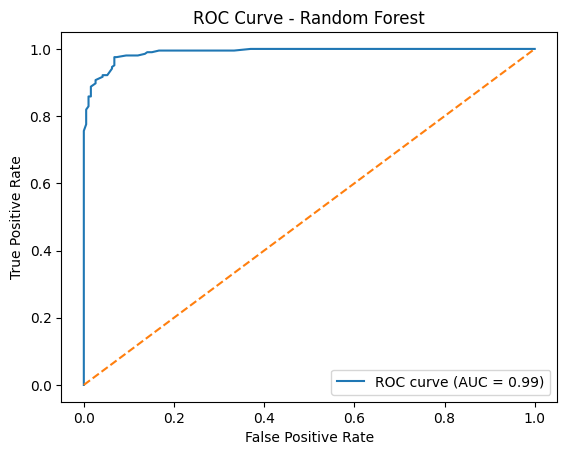

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities (important for ROC)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

In [46]:
y_prob = model.predict_proba(X_test)

In [47]:
confidence = y_prob.max(axis=1)

In [48]:
for i in range(5):
    print(
        "prediction,y_pred[i]"
        "| confidence:",round(confidence[i]*100,2),"%"
    )

prediction,y_pred[i]| confidence: 70.0 %
prediction,y_pred[i]| confidence: 80.0 %
prediction,y_pred[i]| confidence: 95.0 %
prediction,y_pred[i]| confidence: 80.0 %
prediction,y_pred[i]| confidence: 55.0 %
